# Ergodic Trajectory within a specified convex domain

In [1]:
import Pkg; Pkg.activate("../"); Pkg.instantiate()

  Activating project at `~/Documents/adaptive-ocean-exploration-sim`


In [2]:
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

In [3]:
using Plots, Revise, StaticArrays, Interpolations, LinearAlgebra, LazySets

In [4]:
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/Convex_bound_avoidance.jl")

Main.ConvexBoundAvoidance

## Spatial-only Matern-12 Kernel

In [5]:
# Define domain vars
dim = 100; # number of data points along each axis in the domain (defining a square domain)
xstart, xstop = 0, 1.4; # x-axis start and end positions
ystart, ystop = 0, 6.5; # y-axis start and end positions

σ_sq = 1.0
λₓ = 1/(4.0) 

env_data = SyntheticData.matern12_spatial(dim, xstart, xstop, ystart, ystop, σ_sq, λₓ);
# heatmap(range(xstart, stop=xstop, length=dim), range(ystart, stop=ystop, length=dim), env_data; c = :vik)
# title!("Synthetic Data: σ² = $(σ_sq), λₓ = $(λₓ)")

# The domain is (0.15 km x 0.7 km)

Main.SyntheticData.EnvDataSpatial{Vector{Float64}, Matrix{Float64}, Interpolations.Extrapolation{Float64, 2, Interpolations.GriddedInterpolation{Float64, 2, Matrix{Float64}, Gridded{Linear{Throw{OnGrid}}}, Tuple{Vector{Float64}, Vector{Float64}}}, Gridded{Linear{Throw{OnGrid}}}, Throw{Nothing}}}([0.0, 0.014141414141414142, 0.028282828282828285, 0.04242424242424243, 0.05656565656565657, 0.0707070707070707, 0.08484848484848485, 0.09898989898989899, 0.11313131313131314, 0.12727272727272726  …  1.2727272727272727, 1.286868686868687, 1.301010101010101, 1.3151515151515152, 1.3292929292929292, 1.3434343434343434, 1.3575757575757577, 1.3717171717171717, 1.385858585858586, 1.4], [0.0, 0.06565656565656566, 0.13131313131313133, 0.19696969696969696, 0.26262626262626265, 0.3282828282828283, 0.3939393939393939, 0.4595959595959596, 0.5252525252525253, 0.5909090909090909  …  5.909090909090909, 5.974747474747475, 6.040404040404041, 6.106060606060606, 6.171717171717172, 6.237373737373737, 6.303030303030

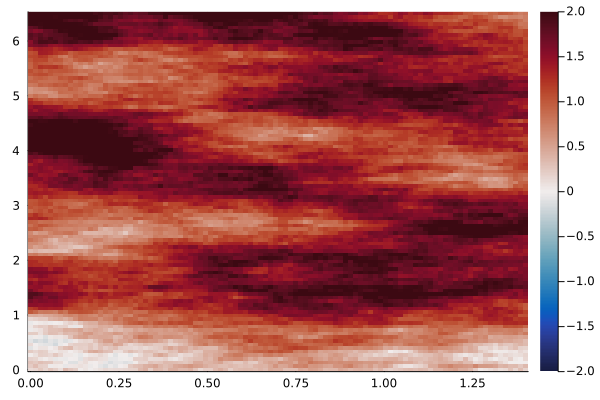

In [6]:
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
plot!(clims=(-2,2))

In [7]:
# Create an ngpkf grid based on the data
# λₓ_wrong = 1/(2.5) 

σ_spatial = σ_sq
# l_spatial = 1/λₓ_wrong
l_spatial = 1/λₓ

res_factor = 0.1 #l_spatial / sqrt(2.0)

kern = NGPKF.MaternKernel(σ_spatial, l_spatial)

ngp_grid_x = range(extrema(env_data.X)..., step= res_factor )
ngp_grid_y = range(extrema(env_data.Y)..., step= res_factor )



# ngp_grid_x = range(extrema(env_data.X)..., length=10) # step= res_factor )
# ngp_grid_y = range(extrema(env_data.Y)..., length=10)# step= res_factor )

0.0:0.1:6.5

In [8]:
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

Main.NGPKF.NGPKFGrid{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{SVector{2, Float64}}, Hermitian{Float64, Matrix{Float64}}, Main.NGPKF.MaternKernel{Float64}}(0.0:0.1:1.4, 0.0:0.1:6.5, SVector{2, Float64}[[0.0, 0.0], [0.1, 0.0], [0.2, 0.0], [0.3, 0.0], [0.4, 0.0], [0.5, 0.0], [0.6, 0.0], [0.7, 0.0], [0.8, 0.0], [0.9, 0.0]  …  [0.5, 6.5], [0.6, 6.5], [0.7, 6.5], [0.8, 6.5], [0.9, 6.5], [1.0, 6.5], [1.1, 6.5], [1.2, 6.5], [1.3, 6.5], [1.4, 6.5]], Main.NGPKF.MaternKernel{Float64}(1.0, 4.0), [32.11146603508154 -17.22686578317242 … 0.00010981957356851491 0.0016688656137622397; -17.22686578317242 44.95568112056273 … 9.131312728210792e-6 0.00010981957357630956; … ; 0.00010981957356851491 9.131312728210792e-6 … 44.95568112056309 -17.226865783172656; 0.0016688656137622397 0.00010981957357630956 … -17.226865783172656 32.11146603508176])

In [9]:
size(ngp_grid_x), size(ngp_grid_y)

((15,), (66,))

In [10]:
@assert maximum(abs.(ngpkf_grid.invK)) < 10.0


AssertionError: AssertionError: maximum(abs.(ngpkf_grid.invK)) < 10.0

In [11]:
# x0s = [@SVector[rand(ngpkf_grid.xs[2:(end-2)]), rand(ngpkf_grid.ys[2:(end-2)])] for i=1:1]
x0s = [@SVector[0.75, 3.0] for i=1:1]

1-element Vector{SVector{2, Float64}}:
 [0.75, 3.0]

In [12]:
[2, 4]

2-element Vector{Int64}:
 2
 4

In [13]:
SimulatorSpatial.measure(0.0, x0s, env_data; σ_meas = 0.05)

1-element Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}:
 Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}(0.0, [0.75, 3.0], 1.4205727188475559)

In [14]:
# Define the Jordan lake domain

VP_Polygon = VPolygon([[0.4, 0],
    [0.7362, 0],
    [1.1925, 4.3707],
    [1.3366, 6.3399],
    [0.2559, 4.7069],
    [0.0398, 1.3929],
])

vertices = [0.4 0.7362 1.1925 1.3366 0.2559 0.0398;
            0 0 4.3707 6.3399 4.7069 1.3929]


# Create a ConvexPolygon object
convex_polygon = ConvexBoundAvoidance.ConvexPolygon(VP_Polygon, vertices)
convex_polygon.edges

2×6 Matrix{Float64}:
 -0.3362  -0.4563  -0.1441  1.0807  0.2161  -0.3602
  0.0     -4.3707  -1.9692  1.633   3.314    1.3929

In [15]:
p = [0.75, 3]
p ∈ convex_polygon.polygon

true

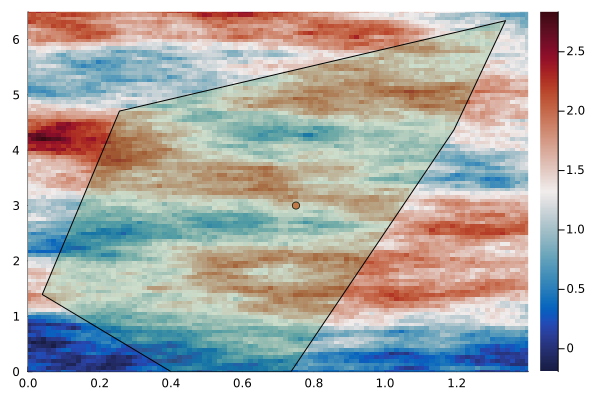

In [16]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
scatter!(first.(x0s), last.(x0s), label = "")
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="")
xlims!(0,1.4)
ylims!(0,6.5)

In [17]:
ΔT = 5.0 / 60.0 # seconds
Tend = 1.0 # hours 
ts = 0.0:(ΔT):(Tend * 60)

0.0:0.08333333333333333:60.0

In [18]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(ΔT)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [19]:
using DifferentialEquations
using ForwardDiff

function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end

C = Cfun(0, 0)
R = Rfun(0, 0)
Q = 0.0
Clarity_decay(u,p,t) = (C^2 / R) * (1-u)^2 - Q * u^2
k = (C^2 / R)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end


function Forward_Simulate_Clarity(current_clarity, target_clarity; fn::Function = Clarity)
    """
    Forward simulate for maximum 10 seconds
    Here for now I only consider the spatiostatic environment 
    """    
    tspan = (0.0, 10.0) # 10 is just chosen to be a huge value for this problem
    u0 = current_clarity
    prob = ODEProblem(fn, u0, tspan)
    condition(u, t, integrator) = u ≥ target_clarity
    affect!(integrator) = terminate!(integrator)
    cb = DiscreteCallback(condition, affect!)
    sol = solve(prob, Tsit5(), callback = cb);
    return sol.t[end]
    
end

Forward_Simulate_Clarity (generic function with 1 method)

In [20]:
# Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

In [21]:
 δt = Forward_Simulate_Clarity(0.1, 0.2; fn = Clarity_decay)

0.42925145522571584

In [22]:
 δt = Clarity_delta_t(0.1, 0.2)

0.4166666666666667

In [23]:
 δt = Clarity_delta_new(0.1, 0.2)

0.4166666666666667

In [24]:
umax=30.0 * 60 / 1000

1.8

In [25]:
using LinearAlgebra, StatsBase

function ergo_controller3(t, xs, convex_polygon; 
        ergo_grid,
        ergo_q_map,
        traj,
        umax= 30.0 * 60 / 1000, # 0.15
        ΔT,
        kwargs...
        )

    target_q = 0.9 ; # * ones(size(ergo_q_map))
    


    # Set the rated value matrix    
    Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)
    target_q_mat = ones(Nx, Ny)
    target_q_mat *= 0.0

    x_domain = range(0, 1.4, length=Nx)
    y_domain = range(0, 6.5, length=Ny)

    for i in 1:length(x_domain)
        for j in 1:length(y_domain)
            p = [x_domain[i], y_domain[j]]
            if p ∈ convex_polygon.polygon
                target_q_mat[i, j] = 0.95
            end
        end
    end

    # Get it in the right shape
    q_target_itp = linear_interpolation((ngpkf_grid.xs, ngpkf_grid.ys), target_q_mat, extrapolation_bc=Interpolations.Line())
    q_target_final = q_target_itp(ErgodicController.xs(ergo_grid), ErgodicController.ys(ergo_grid)) 
    
    target_spatial_dist = zeros(size(ergo_q_map))

    Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

    
    # Only explore the right-hand side of the environment
    for i in CartesianIndices(target_spatial_dist)
        if target_q > ergo_q_map[i]
            target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], q_target_final[i])
        else
            target_spatial_dist[i] = 0.0
        end
    end
    
    # Control input with convex boundary correction
    u = [ErgodicController.controller_single_integrator_cvx_bound(ergo_grid, x, traj, target_spatial_dist, convex_polygon; umax=umax, do_boundary_correction=true) for x in xs]
    
#     # Control input with rectangular boundary correction
#     u = [ErgodicController.controller_single_integrator(ergo_grid, x, traj, target_spatial_dist; umax=umax, do_boundary_correction=false) for x in xs]
    return u

end

ergo_controllers3 = [ergo_controller3 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller3)}:
 ergo_controller3 (generic function with 1 method)

In [28]:
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)
target_q_mat = ones(Nx, Ny)
target_q_mat *= 0.0

x_domain = range(0, 1.4, length=Nx)
y_domain = range(0, 6.5, length=Ny)

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if p ∈ convex_polygon.polygon
            target_q_mat[i, j] = 0.95
        end
    end
end

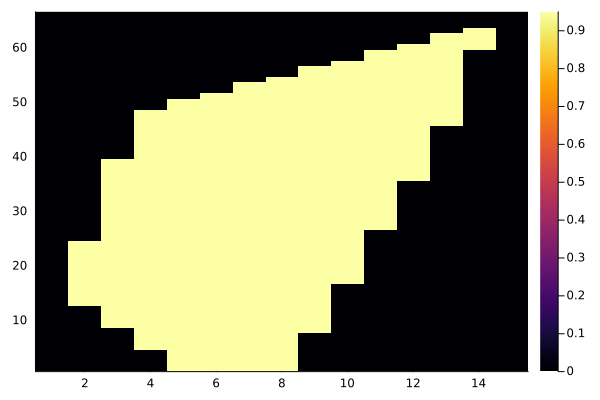

In [29]:
heatmap(target_q_mat')

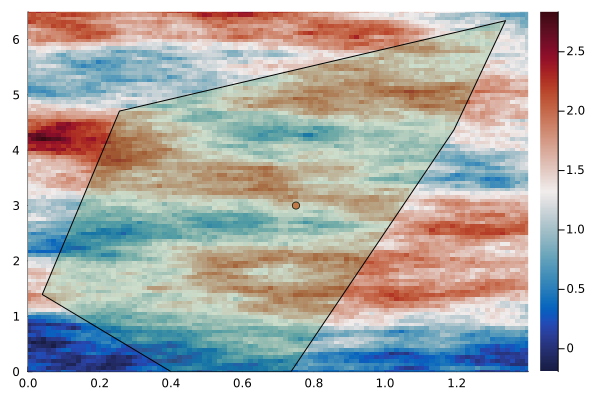

In [30]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
scatter!(first.(x0s), last.(x0s), label = "")
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="")
xlims!(0,1.4)
ylims!(0,6.5)

In [32]:
ΔT = 5.0/120.0 # minutes
Tend = 0.1 # hours 
ts = 0.0:(ΔT):(300)
fuse_measurements_every_ΔT = 5.0 # minutes
recompute_controller_every_ΔT = 5.0 / 120.0 # minutes
σ_t = zeros(15, 66);

In [33]:
5.0/120.0

0.041666666666666664

In [35]:
@time res_ergo =  SimulatorSpatial.simulate_spatial_cvx_bound(ts, x0s, ergo_controller3, convex_polygon; 
    ngpkf_grid=ngpkf_grid, 
    EnvDataSpatial=env_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|                                         |  ETA: N/A
Progress:   1%|▎                                        |  ETA: 0:16:49
Progress:   1%|▍                                        |  ETA: 0:11:06
Progress:   2%|▋                                        |  ETA: 0:09:08


Inside prediction of NGP


Progress:   2%|▉                                        |  ETA: 0:10:00
Progress:   3%|█                                        |  ETA: 0:08:54
Progress:   3%|█▎                                       |  ETA: 0:07:59


Inside prediction of NGP


Progress:   4%|█▌                                       |  ETA: 0:07:20
Progress:   4%|█▋                                       |  ETA: 0:06:50
Progress:   5%|█▉                                       |  ETA: 0:06:25


...

Progress:  97%|███████████████████████████████████████▋ |  ETA: 0:00:08
Progress:  97%|███████████████████████████████████████▉ |  ETA: 0:00:07
Progress:  98%|████████████████████████████████████████ |  ETA: 0:00:06
Progress:  98%|████████████████████████████████████████▎|  ETA: 0:00:04


Inside prediction of NGP


Progress:  99%|████████████████████████████████████████▌|  ETA: 0:00:03
Progress:  99%|████████████████████████████████████████▋|  ETA: 0:00:02
Progress: 100%|████████████████████████████████████████▉|  ETA: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:04:00


246.319072 seconds (4.35 G allocations: 111.285 GiB, 8.98% gc time, 4.33% compilation time)


Main.SimulatorSpatial.SimResult_NonSOC{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}, Vector{Float64}, Vector{Main.KF.KFState{Vector{Float64}, UpperTriangular{Float64, Matrix{Float64}}}}, Vector{Matrix{Float64}}}(0.0:0.041666666666666664:300.0, Vector{SVector{2, Float64}}[[[0.75, 3.0]], [[0.7897097913484981, 3.063624935921844]], [[0.8584798506806703, 3.0935528315954373]], [[0.9216787172400738, 3.133937274956795]], [[0.980010781543848, 3.1810792973366246]], [[1.0171323273135262, 3.2240448755705278]], [[1.0190459481230734, 3.23303438592723]], [[1.0160984830599127, 3.243525087662332]], [[1.0009595014901445, 3.264254223749485]], [[0.9571103117927227, 3.2979191736948947]]  …  [[0.22841480181447116, 3.516992484936474]], [[0.2284148444575233, 3.516993140782421]], [[0.22841488708546837, 3.51

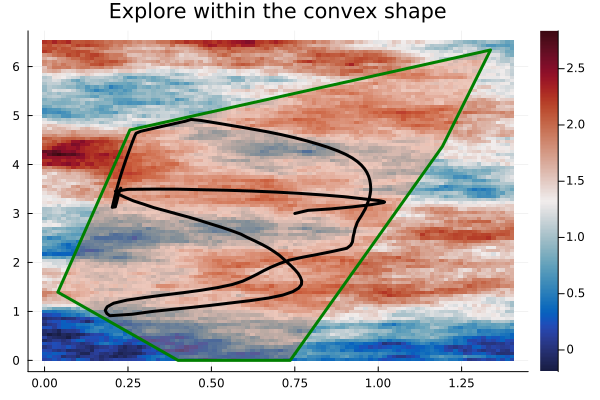

In [36]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.3, linecolor = "green", lw=3,label="")
for i=1:length(x0s)
    x = [r[i][1] for r in res_ergo.xs]
    y = [r[i][2] for r in res_ergo.xs]
    plot!(x,y, linewidth=3, color=:black, label = "")
end
plot!()

# # Define the range for x
# x1 = 5:0.1:20
# x3 = 5:0.1:20
# y2 = 2.0:0.1:8.0

# # Define the constant y
# y1 = 2 .* ones(length(x1))
# y3 = 8 .* ones(length(x1))
# x2 = 5 .* ones(length(y2))
# x4 = 20 .* ones(length(y2))
                    
# # Plot the line
# # Top left box
# plot!(x1, y1, label="", lw=3, color = "green")
# plot!(x2, y2, label="", lw=3, color = "green")
# plot!(x3, y3, label="", lw=3, color = "green")
# plot!(x4, y2, label="", lw=3 ,color = "green")


title!("Explore within the convex shape")

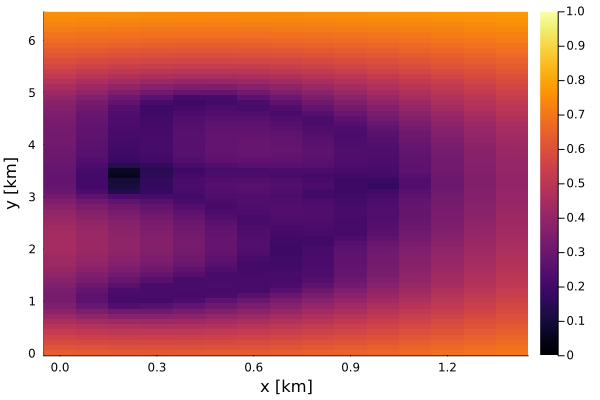

In [37]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)

[ Info: Saved animation to /tmp/jl_VcVkxeT43c.gif


Plots.AnimatedGif("/tmp/jl_VcVkxeT43c.gif")
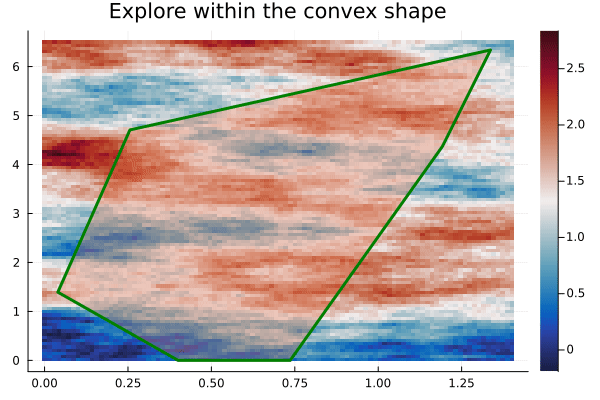

In [38]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
    
    polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.3, linecolor = "green", lw=3,label="")

    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black, label="")
    end
    plot!()
    title!("Explore within the convex shape")
end

In [39]:
gr()
@gif for i=1:length(res_ergo.q_target_maps)
    heatmap(res_ergo.q_target_maps[i]', clims=(0, 1))
    title!("Target clarity map over time: iteration $i")
end

ErrorException: type SimResult_NonSOC has no field q_target_maps

In [40]:
# Comparing two target clarities
gr()
@gif for i=1:length(res_ergo.q_target_maps)
    p0 = heatmap(targetq_scaled_plot', clims=(0, 1))
    p1 = heatmap(res_ergo.q_target_maps[i]', title = "Target Clarity weighted 1")
    p2 = heatmap(res_ergo_exp.q_target_maps[i]', clims=(0, 1), title = "Target clarity weighted exponential")
    plot(p0, p1, p2, layout=@layout[a b c], size=(2000, 350))
#     title!("Weighted coverage")
end

ErrorException: type SimResult_NonSOC has no field q_target_maps

In [41]:
u1 = Float64[]
u2 = Float64[]
speed = Float64[]

for i=1:length(res_ergo.us)
    push!(u1, res_ergo.us[i][1][1])
    push!(u2, res_ergo.us[i][1][2])
    push!(speed, norm(res_ergo.us[i][1]))
end

In [42]:
plot(speed)
ylims!(0., 5.0)

length(speed)
interpolated_times = range(0, stop=170, length=2041)
interpolated_speeds = [v_itp(t) for t in interpolated_times]

UndefVarError: UndefVarError: `v_itp` not defined

In [43]:
v_itp

UndefVarError: UndefVarError: `v_itp` not defined

In [45]:
gr()
plot(interpolated_times, interpolated_speeds, lw=2.0, label="Desired speed profile")
plot!(interpolated_times, speed, linestyle=:dash, lw=2.0, label ="Ergodic speed profile")
ylims!(0., 5.0)
xlabel!("Time [min]")
ylabel!("Speed [km/min]")

UndefVarError: UndefVarError: `interpolated_speeds` not defined

[ Info: Saved animation to /tmp/jl_LG125KrGj4.gif


Plots.AnimatedGif("/tmp/jl_LG125KrGj4.gif")
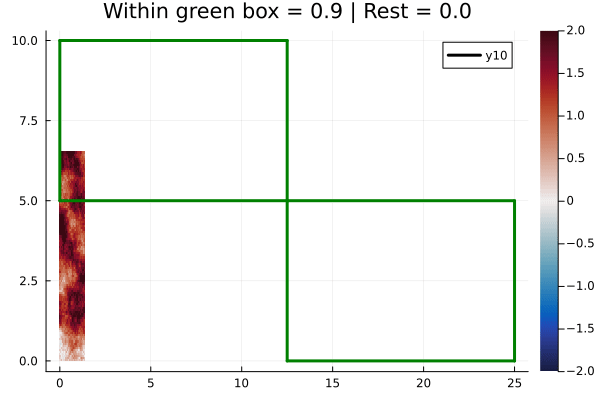

In [47]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))

    # Define the range for x
    x1 = 0:0.1:12.5
    x3 = 0:0.1:12.5
    y2 = 5.0:0.1:10.0
    y4 = 5.0:0.1:10.0
    x5 = 12.5:0.1:25
    y7 = 0:0.1:5.0
    # Define the constant y
    y1 = 5 .* ones(length(x1))
    y3 = 10 .* ones(length(x1))
    x2 = 12.5 .* ones(length(y2))
    x4 = 0.0 .* ones(length(y2))
    y5 = 0.0 .* ones(length(x5))
    y6 = 5.0 .* ones(length(x5))
    x7 = 12.5 .* ones(length(y7))
    x8 = 25 .* ones(length(y7))

    # Plot the line
    # Top left box
    plot!(x1, y1, label="", lw=3, color = "green")
    plot!(x2, y2, label="", lw=3, color = "green")
    plot!(x3, y3, label="", lw=3, color = "green")
    plot!(x4, y4, label="", lw=3 ,color = "green")

    # Bottom right box 
    plot!(x5, y5, label="", lw=3, color = "green")
    plot!(x5, y6, label="", lw=3, color = "green")
    plot!(x7, y7, label="", lw=3, color = "green")
    plot!(x8, y7, label="", lw=3 ,color = "green")

    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black)
    end
    plot!()
    title!("Within green box = 0.9 | Rest = 0.0")
end

# # Plot line 
# # Define the constant y
# # Define the range for x
# x1 = 0:0.1:25

# # Define the constant y
# y1 = 5 .* ones(length(x1))

# # Plot the line
# plot!(x1, y1, label="", lw=5)


In [48]:
size(res_ergo.w_hats)

(60,)

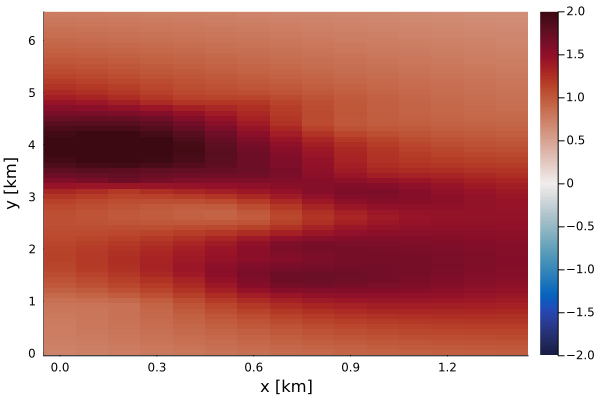

In [49]:
gr()

p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2))


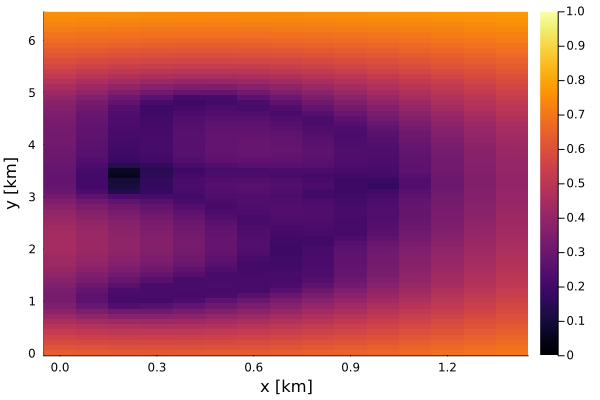

In [50]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)
# for i=1:length(x0s)
#     x = [r[i][1] for r in res_ergo.xs]
#     y = [r[i][2] for r in res_ergo.xs]
#     plot!(x, y, linewidth=3)
# end
plot!()

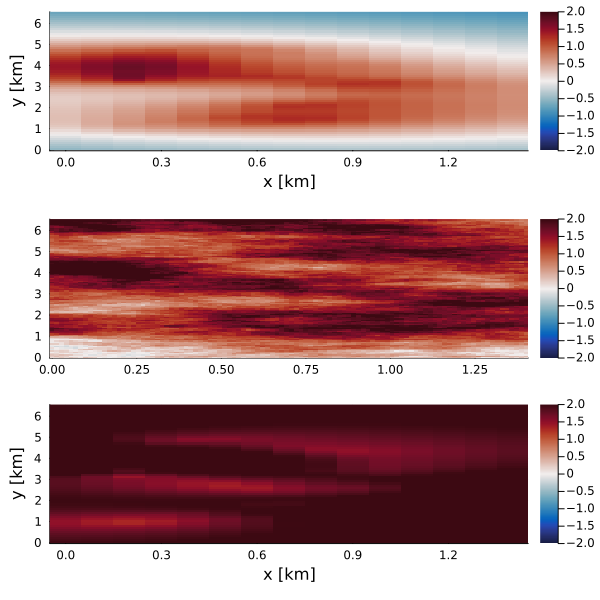

In [51]:
gr()

p1 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_min=true)
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_max=true)
p3 = heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
    
plot(p1, p3, p2, layout = (@layout [a;b; c]), size=[600, 600])

In [52]:
# Compute RMSE

Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)

M = reshape(KF.μ(res_ergo.w_hats[end]), Nx, Ny)
heatmap(M',colormap=:balance, clims=(-2,2) )
x_new = 0:0.4:25
y_new = 0:0.4:10
Data_sampled = [env_data.itp_w(xi, yi) for yi in y_new, xi in x_new]
Diff = M' .- Data_sampled
rmse = sqrt(mean(Diff .^ 2))

BoundsError: BoundsError: attempt to access 100×100 extrapolate(interpolate((::Vector{Float64},::Vector{Float64}), ::Matrix{Float64}, Gridded(Linear())), Throw()) with element type Float64 at index [0.0, 6.8]

In [53]:
heatmap(Data_sampled,colormap=:balance, clims=(-2,2))

UndefVarError: UndefVarError: `Data_sampled` not defined

In [54]:
# Compute Precision

σ_prec = KF.σ(res_ergo.w_hats[end])
M_prec = reshape(σ_prec, Nx, Ny)
precision = sum(M_prec)/length(M_prec)

0.4094816580974249

In [59]:
using LinearAlgebra, StatsBase

mean_deficit_1 = [mean(map( c -> max(0, 1.0 - c), q )) for q in res_ergo.ergo_q_maps]
mean_deficit_1[end]

0.14642813815486258

In [60]:
ts = range(1, 100, 20)
time = collect(ts)

20-element Vector{Float64}:
   1.0
   6.2105263157894735
  11.421052631578947
  16.63157894736842
  21.842105263157894
  27.05263157894737
  32.26315789473684
  37.473684210526315
  42.68421052631579
  47.89473684210526
  53.10526315789474
  58.31578947368421
  63.526315789473685
  68.73684210526316
  73.94736842105263
  79.15789473684211
  84.36842105263158
  89.57894736842105
  94.78947368421052
 100.0

In [61]:
# plot(res_ergo.w_hat_ts, mean_deficit_1, marker=:dot)
gr()
plot()
plot!(time, mean_deficit_1, marker=:dot)
ylabel!("Clarity Deficit[0,1]")
xlabel!("Time [min]")
ylims!(0., 0.6)

┌ Warning: Keyword argument markerstrokestyle not supported with
│ Plots.GRBackend(). Choose from: annotationcolor, annotationfontfamily,
│ annotationfontsize, annotationhalign, annotationrotation, annotations,
│ annotationvalign, arrow, aspectratio, axis, backgroundcolor,
│ backgroundcolorinside, backgroundcoloroutside, backgroundcolorsubplot,
│ barwidth, bins, bottommargin, camera, clims, colorpalette, colorbar,
│ colorbarentry, colorbarscale, colorbartitle, colorbartitlefont,
│ colorbartitlefontcolor, colorbartitlefontrotation, colorbartitlefontsize,
│ connections, contourlabels, discretevalues, fill, fillz, fillalpha,
│ fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamilysubplot,
│ foregroundcolor, foregroundcoloraxis, foregroundcolorborder,
│ foregroundcolorgrid, foregroundcolorsubplot, foregroundcolortext,
│ formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group,
│ guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign,
│ guidefontrotation, g